# Agglomerative Clustering From Scratch

This Jupyter Notebook provides a detailed, step-by-step guide on
implementing the Agglomerative Clustering algorithm from scratch.
It covers the following key areas:

- Sample data points
- Initialize pairwise distance matrix
- Iteratively merge clusters based on *single linkage*
- Visualize the clustering process at each step

In [1]:
import random
import numpy as np
from scipy.spatial.distance import pdist, squareform

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

cmap = plt.get_cmap('tab10')
colors = [cmap(i) for i in range(cmap.N)]

mpl.rcParams["font.size"] = 24
mpl.rcParams["lines.linewidth"] = 2

seed = 0
random.seed(seed)
np.random.seed(seed)
n_samples = 10
markersize = 100

## Sample data points

In [2]:
m1 = [1, 1]
cov1 = [[1, 0], [0, 1]]
s1 = np.random.multivariate_normal(m1, cov1, 5)

m2 = [-1, -1]
cov2 = [[1, -0.5], [-0.5, 1]]
s2 = np.random.multivariate_normal(m2, cov2, 5)

samples = np.concat([s1, s2])
np.random.shuffle(samples)

(np.float64(-2.659691942232599),
 np.float64(3.1307603678824707),
 np.float64(-1.3757641112226862),
 np.float64(3.4607340235073694))

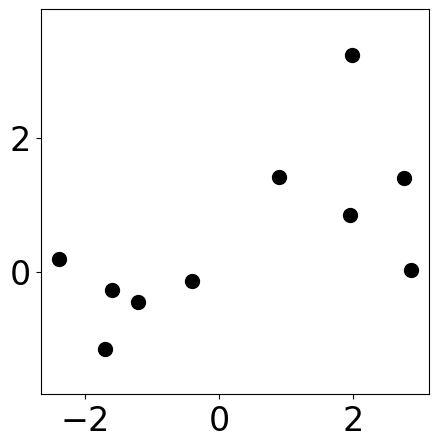

In [3]:
plt.figure(figsize=(5, 5))
plt.scatter(samples[:, 0], samples[:, 1], s=markersize, color="k")
# plt.axis("off")
plt.xlim([-2, 2])
plt.ylim([-2, 2])
plt.axis("equal")

## Initialize pairwise distance matrix

In [4]:
def agglomerative_clustering(points, n_clusters):
    n_points = points.shape[0]
    cur_clusters = n_points
    clusters = {i: [i] for i in range(n_points)}
    distances = squareform(pdist(points))
    np.fill_diagonal(distances, np.inf)

    merge_list = []
    labels_list = []

    while cur_clusters > n_clusters:
        # single-linkage
        idx = np.argmin(distances)
        i, j = int(idx//n_points), int(idx%n_points)

        merge_list.append((i, j))

        # merge datapoints in cluster i and j
        clusters[i].extend(clusters[j])
        for k in clusters:
            if k != i:
                distances[i, k] = distances[k, i] = min(distances[i, k], distances[j, k])

        # remove cluster j
        clusters.pop(j)
        cur_clusters -= 1
        distances[:, j] = np.inf
        distances[j, :] = np.inf

        # assign labels
        labels = np.zeros(n_points, dtype=int)
        for cluster_id, points in clusters.items():
            for point in points:
                labels[point] = cluster_id
        labels_list.append(labels)

    return labels_list, merge_list


In [5]:
k = 2
labels_list, merge_list = agglomerative_clustering(samples, k)

Initial clusters

(np.float64(-2.659691942232599),
 np.float64(3.1307603678824707),
 np.float64(-1.3757641112226862),
 np.float64(3.4607340235073694))

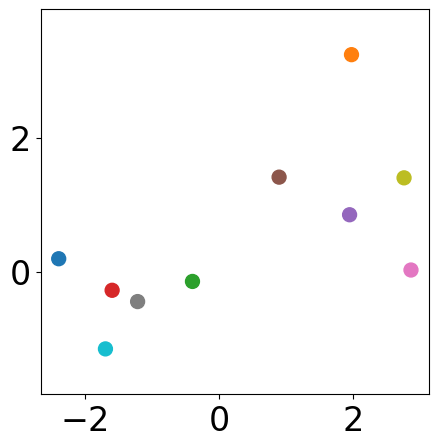

In [6]:
plt.figure(figsize=(5, 5))
plt.scatter(samples[:, 0], samples[:, 1],
            s=markersize, color=colors)
# plt.axis("off")
plt.axis("equal")

After $i$ steps

(np.float64(-2.659691942232599),
 np.float64(3.1307603678824707),
 np.float64(-1.3757641112226862),
 np.float64(3.4607340235073694))

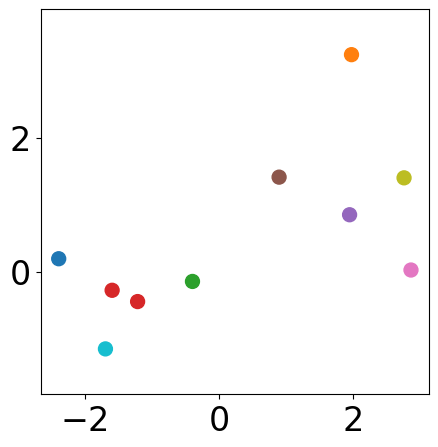

In [7]:
# modify this index to visualize results step-by-step
step_idx = 0 # after the first step

plt.figure(figsize=(5, 5))
plt.scatter(samples[:, 0], samples[:, 1],
            s=markersize, color=[colors[l] for l in labels_list[step_idx]])
# plt.axis("off")
plt.axis("equal")

Final results

(np.float64(-2.659691942232599),
 np.float64(3.1307603678824707),
 np.float64(-1.3757641112226862),
 np.float64(3.4607340235073694))

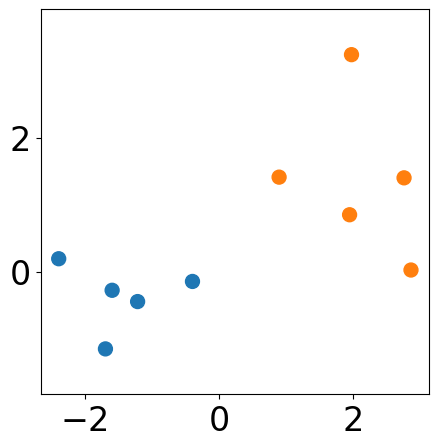

In [8]:
plt.figure(figsize=(5, 5))
plt.scatter(samples[:, 0], samples[:, 1],
            s=markersize, color=[colors[l] for l in labels_list[-1]])
# plt.axis("off")
plt.axis("equal")